In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [13]:
df = pd.read_csv('data/diabetes.csv')

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


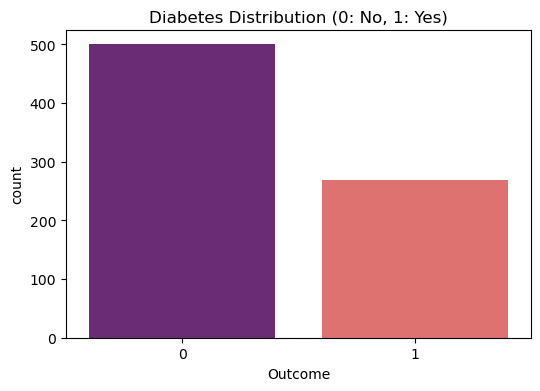

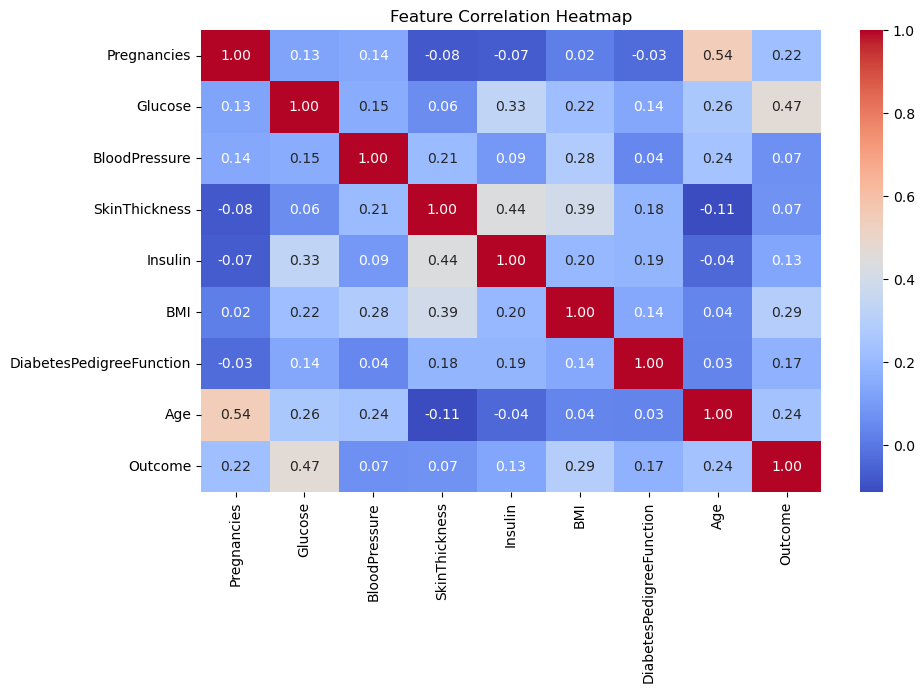

In [14]:
print("First 5 rows:")
print(df.head())

plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df, hue='Outcome', palette='magma', legend=False)
plt.title('Diabetes Distribution (0: No, 1: Yes)')
plt.show()


plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [15]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [16]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'BMI', 'Insulin', 'SkinThickness']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)
df.fillna(df.median(), inplace=True)

In [17]:
X = df.drop('Outcome', axis=1) # Features
y = df['Outcome']              # Target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [18]:
print("\n--- Preprocessing Status ---")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print("Data scaling and splitting completed successfully.")


--- Preprocessing Status ---
Training set size: 614 samples
Testing set size: 154 samples
Data scaling and splitting completed successfully.


In [19]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}


================ Logistic Regression ================
Accuracy Score: 0.7532

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



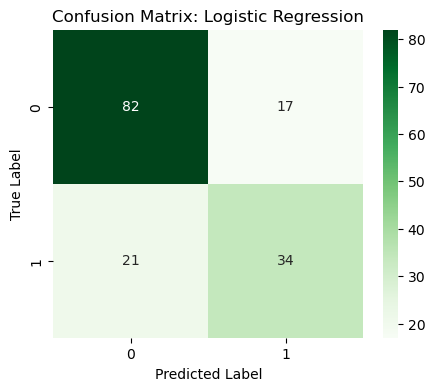


================ Random Forest ================
Accuracy Score: 0.7403

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.79      0.80        99
           1       0.63      0.65      0.64        55

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154



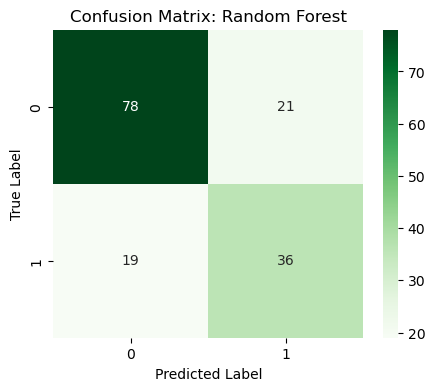

/var/folders/xk/1rld6vfd1wg4hnmdkv7sx_b00000gn/T/ipykernel_42040/504191954.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


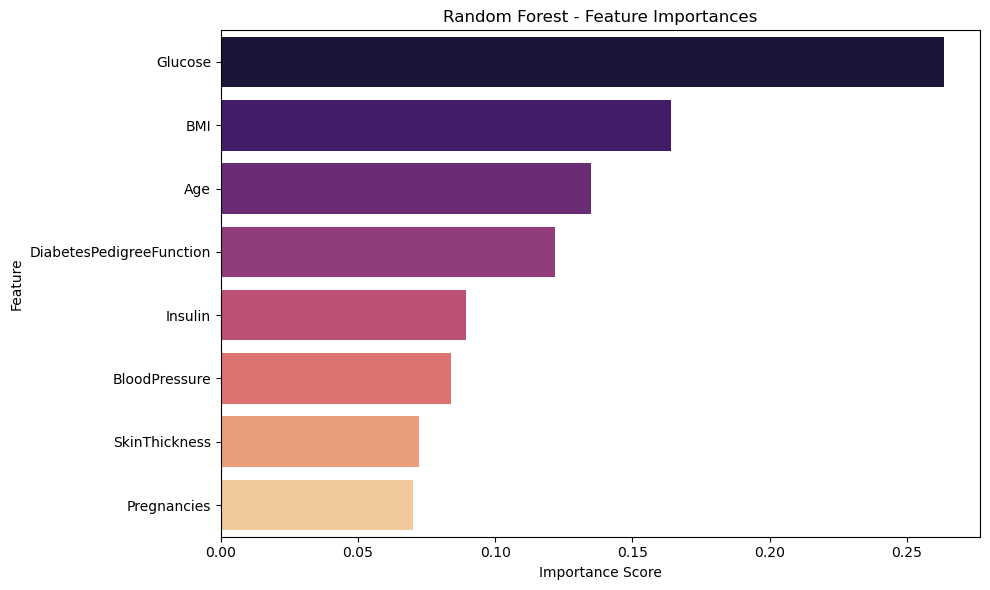


Top 10 Most Important Features:
  1. Glucose: 0.2635
  2. BMI: 0.1641
  3. Age: 0.1349
  4. DiabetesPedigreeFunction: 0.1219
  5. Insulin: 0.0893
  6. BloodPressure: 0.0840
  7. SkinThickness: 0.0724
  8. Pregnancies: 0.0699

--- Final Model Comparison ---
Logistic Regression: 75.32%
Random Forest: 74.03%


In [23]:
results = {}

for name, model in models.items():
    
    model.fit(X_train, y_train)
   
    y_pred = model.predict(X_test)
    
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n================ {name} ================")
    print(f"Accuracy Score: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    if name == "Random Forest":
        feature_names = df.drop(columns=['Outcome']).columns  
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]

        plt.figure(figsize=(10, 6))
        sns.barplot(
            x=importances[indices],
            y=feature_names[indices],
            palette='magma'
        )
        plt.title('Random Forest - Feature Importances')
        plt.xlabel('Importance Score')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()

        print("\nTop 10 Most Important Features:")
        for i in range(min(10, len(feature_names))):
            print(f"  {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")


print("\n--- Final Model Comparison ---")
for model_name, score in results.items():
    print(f"{model_name}: {score*100:.2f}%")